<a href="https://colab.research.google.com/github/sanjana19991118/python_ml/blob/main/Feature_Engineering_Sanjana.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd

df = pd.read_excel('/content/Graded Assignment 1 Dataset.xlsx')
display(df.head())

,age,income,credit_score,loan_amount,monthly_spend,experience_years,employment_type,education_level,region,risk_tolerance,financial_capacity_index,household_cashflow_score,behavior_score,loan_default
0,43.960570,31019.390823,650.336822,33805.550343,1732.298149,13,salaried,bachelor,east,high,31.019391,38.732577,38.393095,0
1,36.340828,39375.961557,648.261012,20974.755713,2334.610693,32,salaried,bachelor,north,high,39.375962,45.595276,62.162754,0
2,45.772262,18055.668704,554.304978,26027.339787,1848.435993,1,salaried,bachelor,south,low,18.055669,15.033732,51.200728,1
3,56.276358,15254.929250,656.893687,20798.610521,3256.259548,1,unemployed,master,east,low,15.254929,25.533778,73.122834,0
4,35.190160,11486.292927,731.298036,14661.332950,7767.804367,30,salaried,master,west,low,11.486293,6.237571,52.571462,0


Task 1.Dataset Understanding and Exploratory Data Analysis (EDA)


*   identification of numeric and categorical features
*   summary statistics of key variables
*   identification of missing values
*   inspection of feature distributions







In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Initial inspection
print("----Data Info:----")
print(df.info())
print("\n----First 5 rows:---")
print(df.head())
print("\n---Missing Values:----")
print(df.isnull().sum())

----Data Info:----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       2375 non-null   float64
 1   income                    2500 non-null   float64
 2   credit_score              2300 non-null   float64
 3   loan_amount               2500 non-null   float64
 4   monthly_spend             2500 non-null   float64
 5   experience_years          2500 non-null   int64  
 6   employment_type           2375 non-null   object 
 7   education_level           2500 non-null   object 
 8   region                    2500 non-null   object 
 9   risk_tolerance            2500 non-null   object 
 10  financial_capacity_index  2500 non-null   float64
 11  household_cashflow_score  2500 non-null   float64
 12  behavior_score            2500 non-null   float64
 13  loan_default              2500 non-null   in

**Numeric Features ($10$ total):** Variables such as age, income, credit_score, and loan_amount. These represent continuous or discrete measurements and are suitable for statistical analysis and scaling

**Categorical Features ($4$ total):** Variables such as employment_type, education_level, region, and risk_tolerance. These represent groupings and require encoding (Label or One-Hot) for machine learning models.

Numeric Features: ['age', 'income', 'credit_score', 'loan_amount', 'monthly_spend', 'experience_years', 'financial_capacity_index', 'household_cashflow_score', 'behavior_score', 'loan_default']
Categorical Features: ['employment_type', 'education_level', 'region', 'risk_tolerance']

Missing Values Before Imputation:
 Series([], dtype: int64)


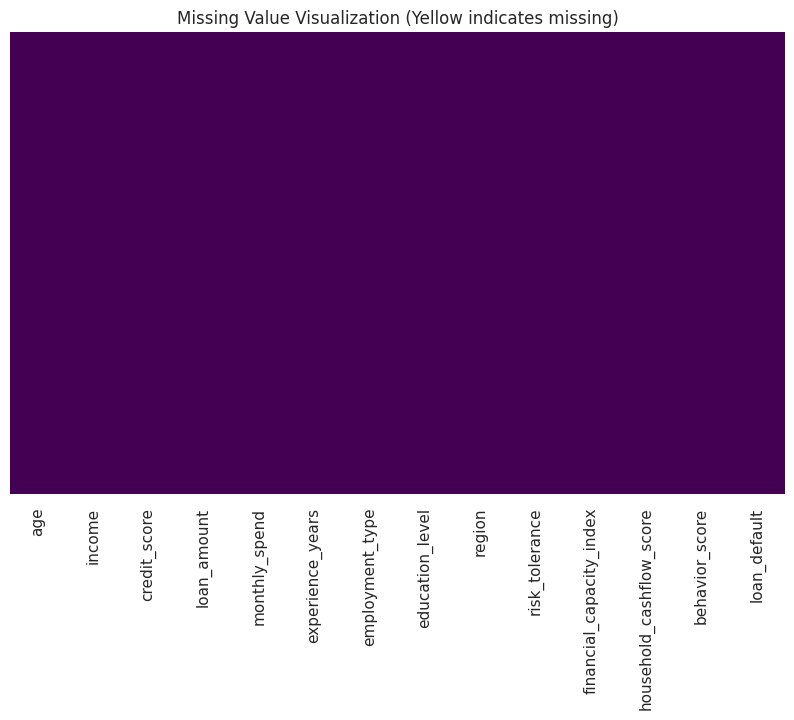

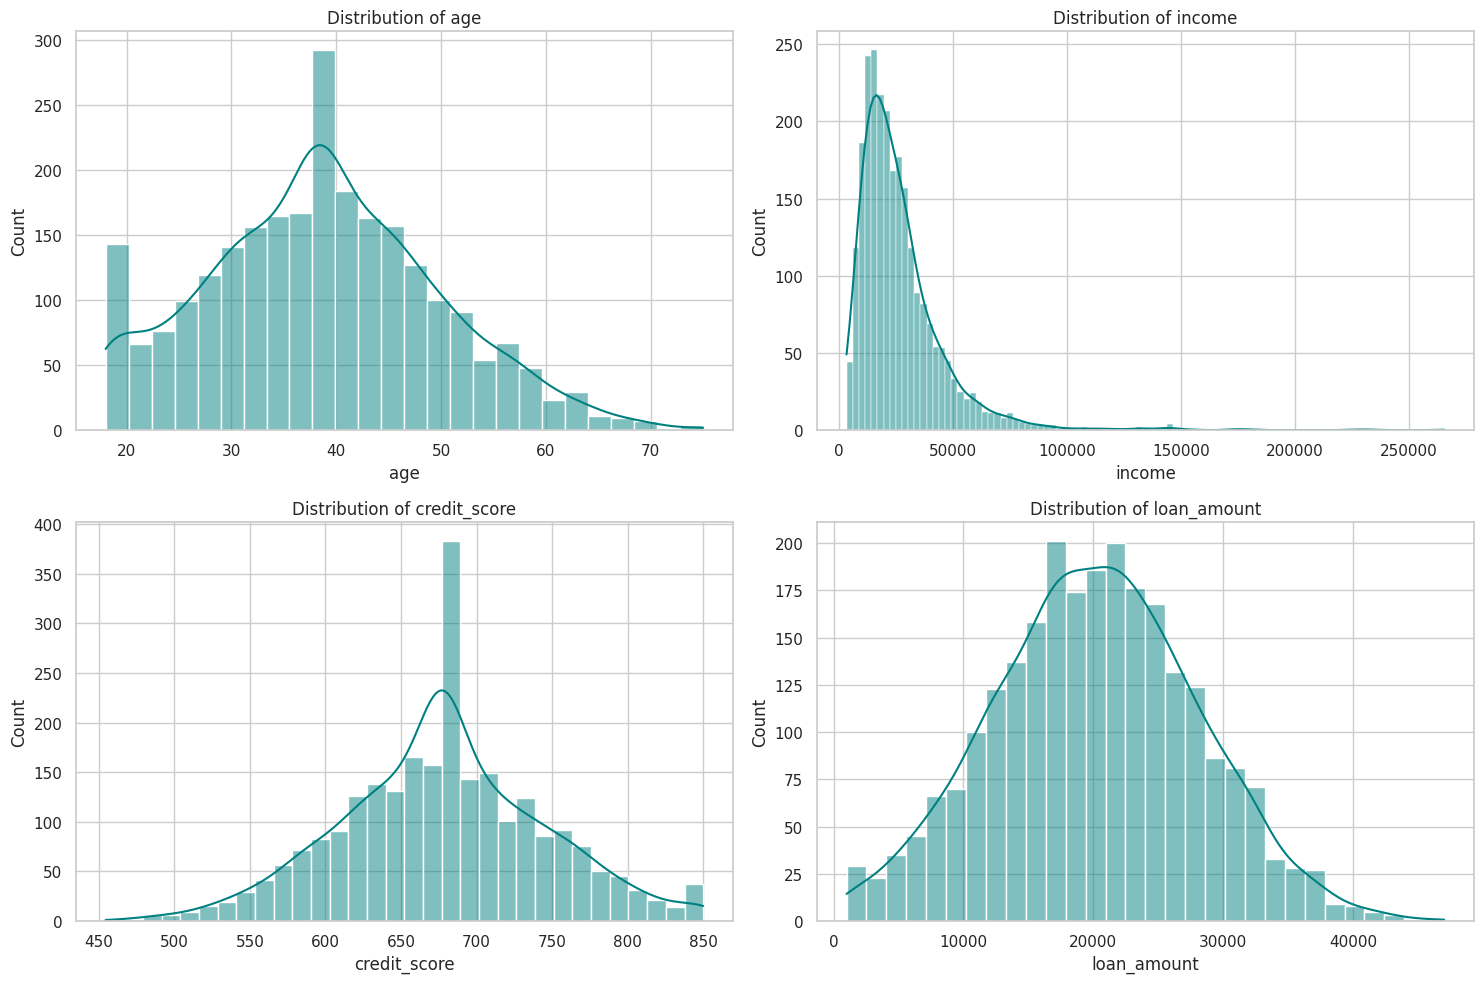

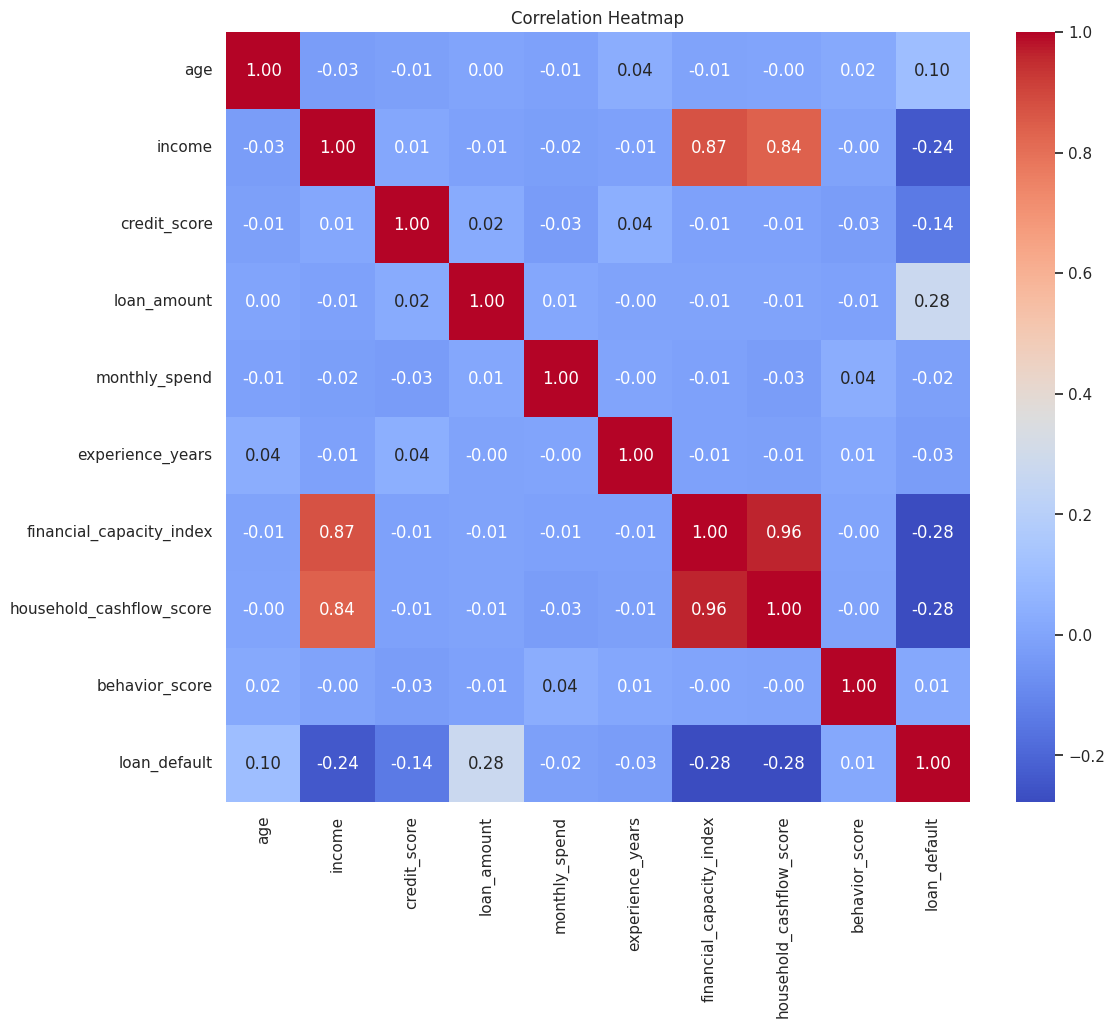

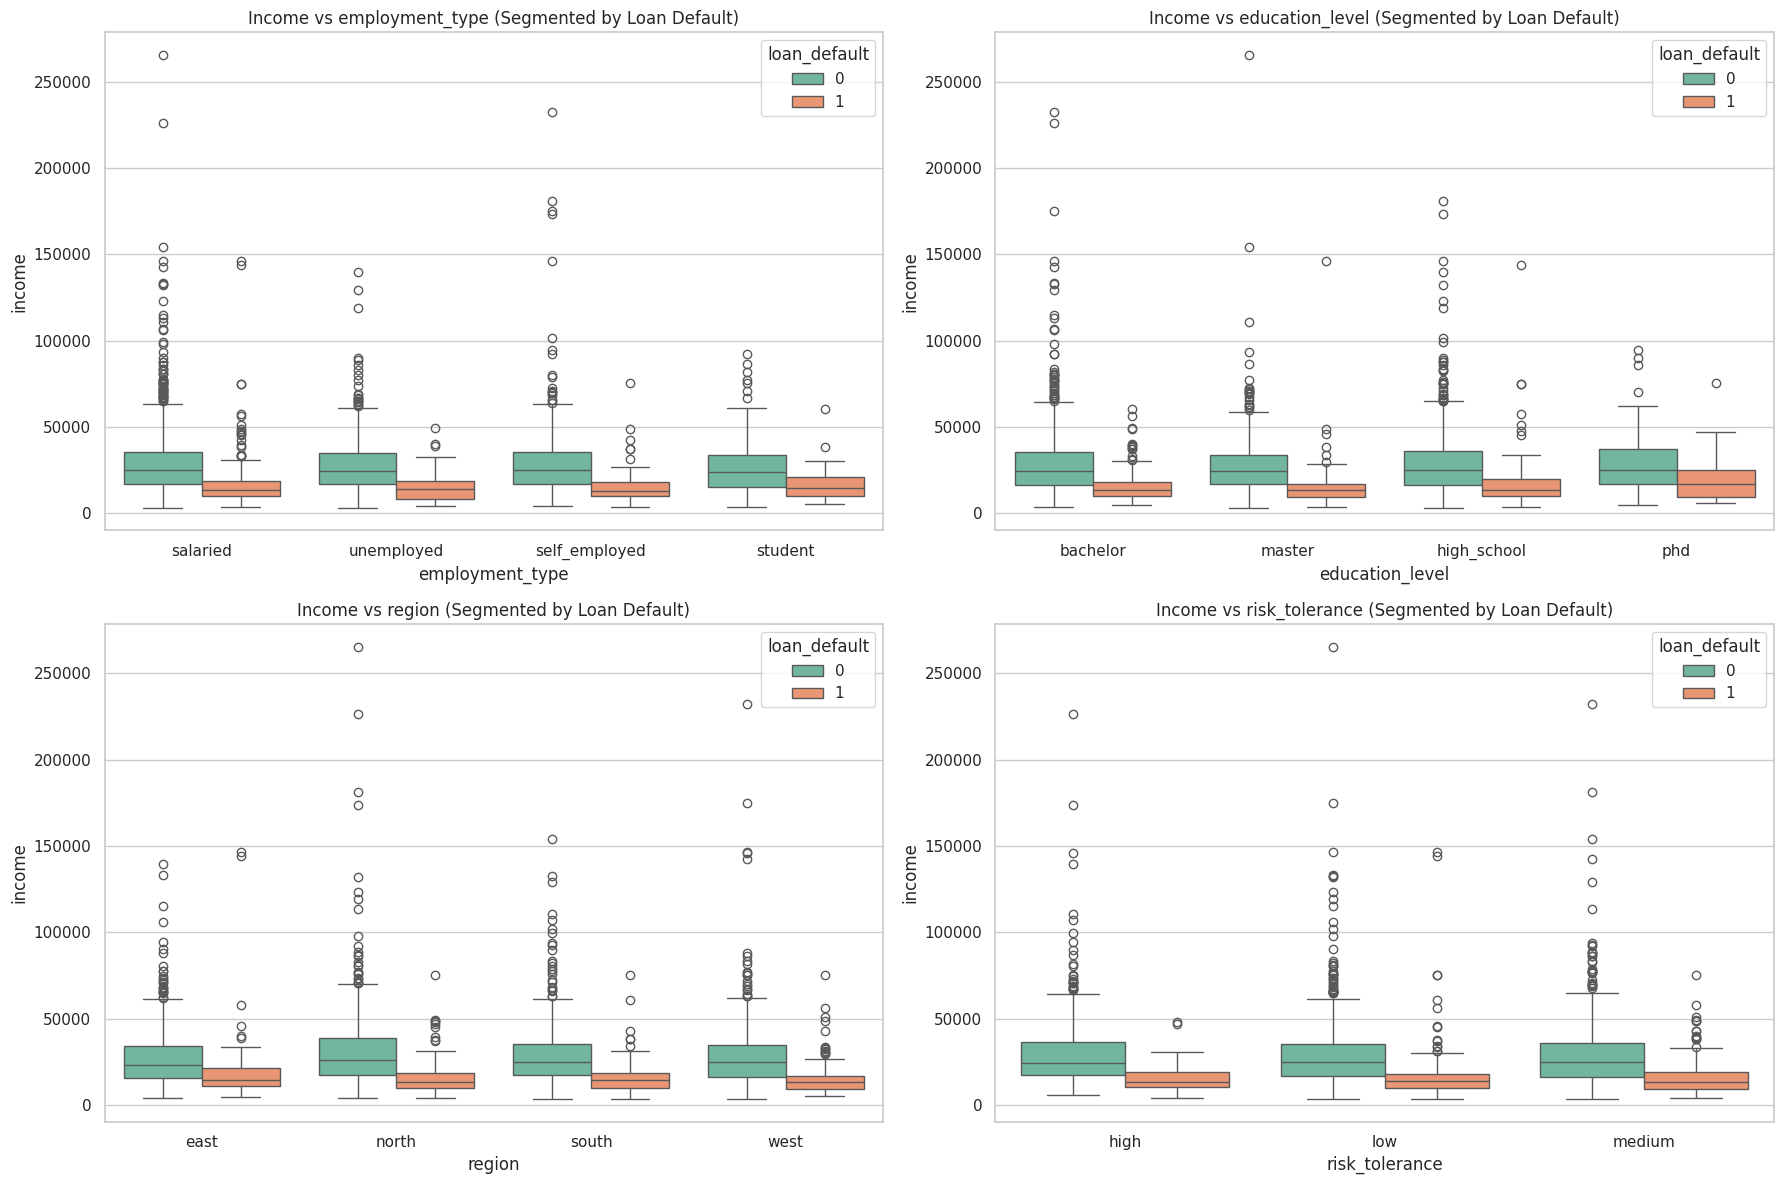


Preprocessing complete. Processed data contains 21 features.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Set consistent visual theme
sns.set_theme(style="whitegrid")

# --- 2. Identification of numeric and categorical features ---
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Numeric Features: {numeric_features}")
print(f"Categorical Features: {categorical_features}")

# --- 3. Identification and Handling of Missing Values ---
missing_info = df.isnull().sum()
print("\nMissing Values Before Imputation:\n", missing_info[missing_info > 0])

# Missing Value Visualization (Heatmap)
# This shows exactly where the data is missing across the rows
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Value Visualization (Yellow indicates missing)')
plt.show()

# Imputation Decision: Median for numeric, Mode for categorical
df['age'] = df['age'].fillna(df['age'].median())
df['credit_score'] = df['credit_score'].fillna(df['credit_score'].median())
df['employment_type'] = df['employment_type'].fillna(df['employment_type'].mode()[0])

# --- 4. Feature Transformations & Justification ---

# Transformation 1: One-Hot Encoding
# Justification: Converts categories to a format readable by ML models
# without implying a numerical order (e.g., East is not "greater than" West).
df_processed = pd.get_dummies(df, columns=categorical_features, drop_first=True)

# Transformation 2: Feature Scaling (Standardization)
# Justification: Features like 'income' and 'age' have vastly different ranges.
# Scaling prevents high-magnitude features from dominating the model's logic.
scaler = StandardScaler()
cols_to_scale = [col for col in numeric_features if col != 'loan_default']
df_processed[cols_to_scale] = scaler.fit_transform(df_processed[cols_to_scale])

# --- 5. Visualizations & Explanations ---

# V2: Distribution plots for key numeric features
plt.figure(figsize=(15, 10))
key_numeric = ['age', 'income', 'credit_score', 'loan_amount']
for i, col in enumerate(key_numeric, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col], kde=True, color='teal')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

# V3: Correlation heatmap for numeric features
plt.figure(figsize=(12, 10))
sns.heatmap(df[numeric_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

# V4: Boxplots showing categorical features vs loan_default
# Fix: Using 'hue' to avoid FutureWarnings and show the target relationship
plt.figure(figsize=(18, 12))
for i, col in enumerate(categorical_features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=df, x=col, y='income', hue='loan_default', palette='Set2')
    plt.title(f'Income vs {col} (Segmented by Loan Default)')
plt.tight_layout()
plt.show()

print("\nPreprocessing complete. Processed data contains", len(df_processed.columns), "features.")

**Distribution Plots (Numeric Features)**

The histograms confirmed that while age is relatively normally distributed, financial variables like income are skewed.

This observation justifies the need for Log Transformations or Standardization later in the pipeline to ensure the model isn't biased toward extreme values.

**Missing Value Visualization**

The heatmap provided a "spatial" view of data gaps. Since the missing values appeared randomly distributed rather than concentrated in specific patterns, the approach was Median Imputation for numeric values and Mode Imputation for categories to preserve as much data as possible.

**Correlation Heatmap**

The heatmap revealed the "drivers" of loan default:

Strong Predictors: financial_capacity_index and loan_amount showed the strongest correlations with loan_default.

Redundancy: We discovered a very high correlation ($> 0.95$) between financial_capacity_index and household_cashflow_score. This identifies multicollinearity, suggesting that one of these features is redundant and should be removed to simplify the model.

**Boxplots (Categorical vs. Loan Default)**

By plotting income across categories like employment_type and region while segmenting by loan_default, we observed:
Default Patterns: Defaulters (target = $1$) consistently show lower median incomes and lower credit scores across all geographic regions and education levels.

Risk Groups: Certain groups, such as the unemployed or those with low risk tolerance, showed a tighter distribution of income among defaulters, making them easier to distinguish from non-defaulters.

**Conclusion**
The EDA phase confirmed that the dataset is rich in predictive signals but requires careful handling of missing values, skewness, and multicollinearity before it can be used for reliable modeling.

Numeric Features: ['age', 'income', 'credit_score', 'loan_amount', 'monthly_spend', 'experience_years', 'financial_capacity_index', 'household_cashflow_score', 'behavior_score', 'loan_default']
Categorical Features: ['employment_type', 'education_level', 'region', 'risk_tolerance']

Missing Values Before Imputation:
 Series([], dtype: int64)


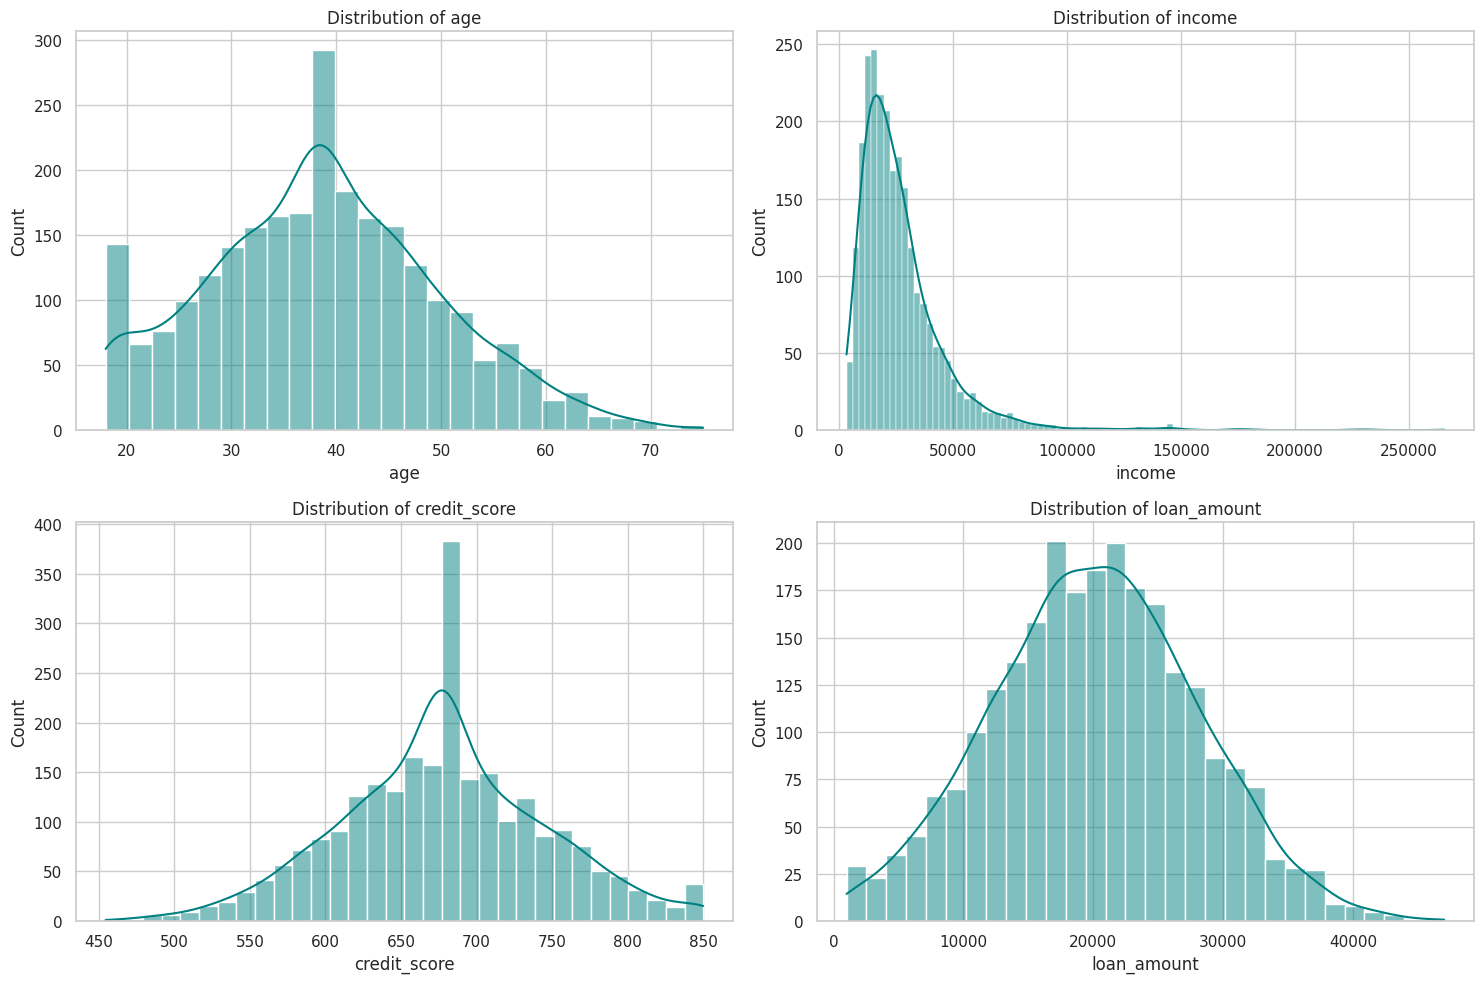

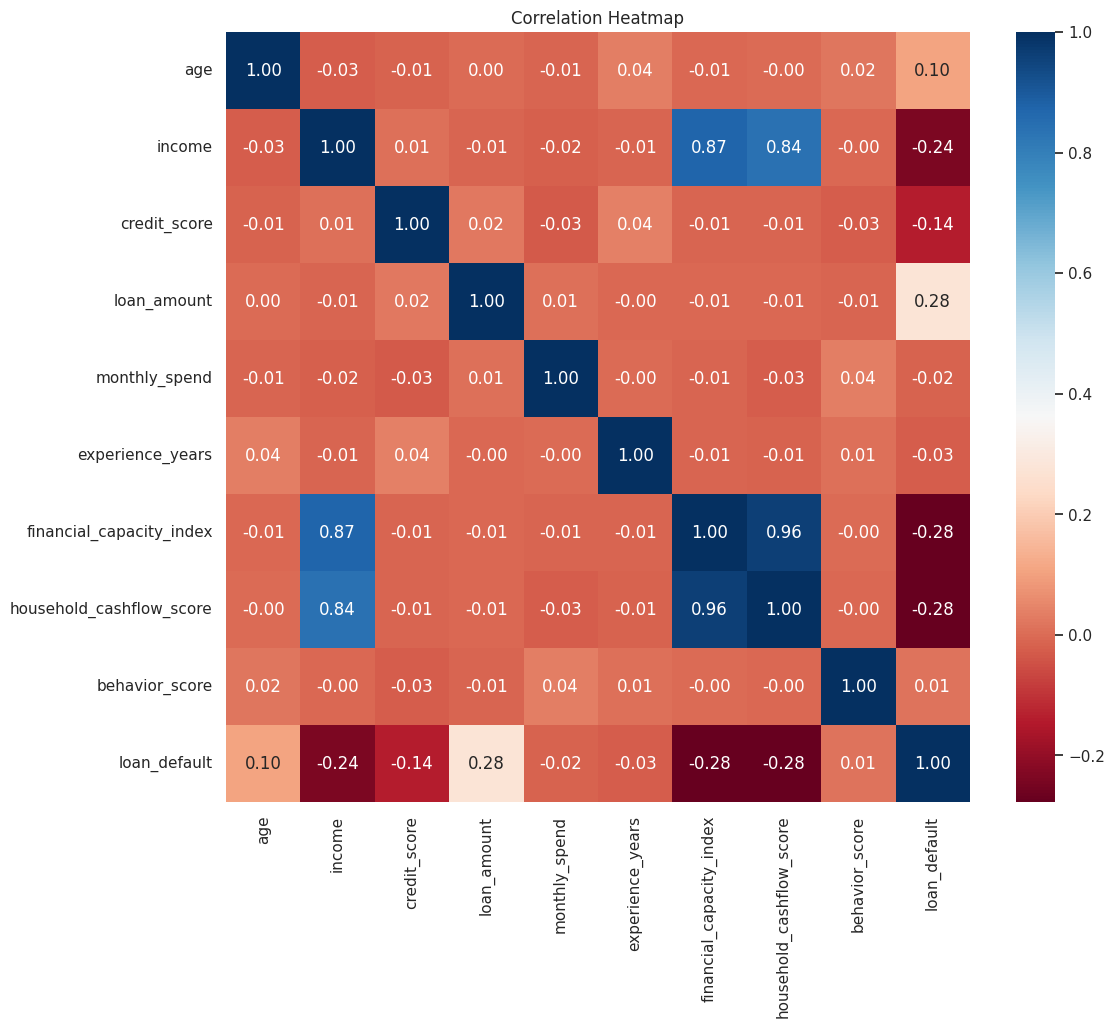

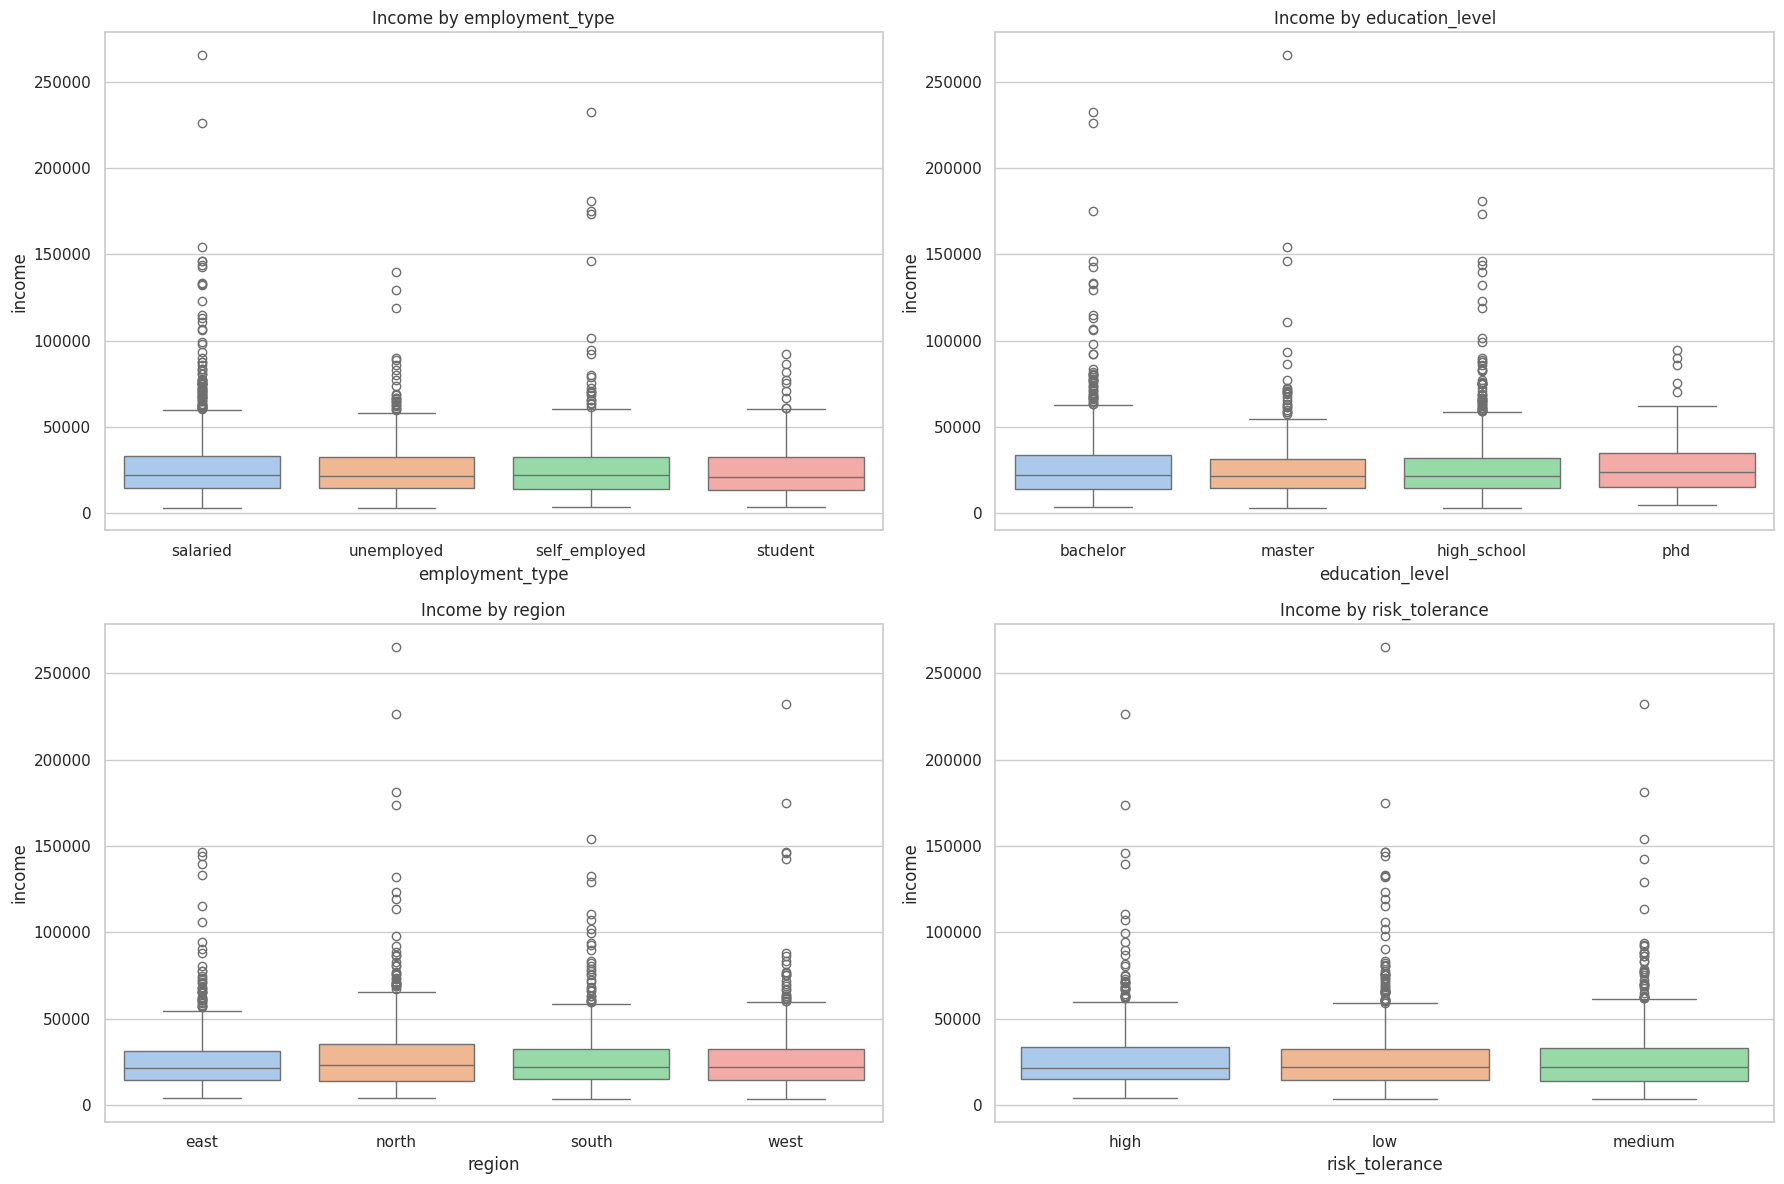


Preprocessing complete. Processed data contains 21 features.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Set consistent visual theme
sns.set_theme(style="whitegrid")



# --- 2. Identification of numeric and categorical features ---
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Numeric Features: {numeric_features}")
print(f"Categorical Features: {categorical_features}")

# --- 3. Identification and Handling of Missing Values ---
# Decision: Impute missing numerical data with median and categorical with mode
missing_info = df.isnull().sum()
print("\nMissing Values Before Imputation:\n", missing_info[missing_info > 0])

df['age'] = df['age'].fillna(df['age'].median())
df['credit_score'] = df['credit_score'].fillna(df['credit_score'].median())
df['employment_type'] = df['employment_type'].fillna(df['employment_type'].mode()[0])

# --- 4. Feature Transformations & Justification ---

# Transformation 1: One-Hot Encoding for Categorical Variables
# Justification: Most ML algorithms require numeric input. One-hot encoding
# prevents the model from assuming a false mathematical hierarchy (e.g.,
# assuming 'PhD' is "greater than" 'Bachelor' in a way that biases distance).
df_processed = pd.get_dummies(df, columns=categorical_features, drop_first=True)

# Transformation 2: Feature Scaling (Standardization)
# Justification: Features like 'income' (ranging up to $265k$) and 'age' (up to $75$)
# have different scales. StandardScaler transforms them to have a mean of 0
# and a standard deviation of 1, ensuring no single feature dominates the model.
scaler = StandardScaler()
cols_to_scale = [col for col in numeric_features if col != 'loan_default']
df_processed[cols_to_scale] = scaler.fit_transform(df_processed[cols_to_scale])

# --- 5. Visualizations ---

# V1: Distribution plots for key numeric features
plt.figure(figsize=(15, 10))
key_numeric = ['age', 'income', 'credit_score', 'loan_amount']
for i, col in enumerate(key_numeric, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col], kde=True, color='teal')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

# V2: Correlation heatmap for numeric features
plt.figure(figsize=(12, 10))
sns.heatmap(df[numeric_features].corr(), annot=True, cmap='RdBu', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

# V3: Boxplots (Categorical features vs Income/Target)
# Note: Assigning 'x' to 'hue' to fix the Seaborn palette FutureWarning
plt.figure(figsize=(18, 12))
for i, col in enumerate(categorical_features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=df, x=col, y='income', hue=col, palette='pastel')
    plt.title(f'Income by {col}')
plt.tight_layout()
plt.show()

print("\nPreprocessing complete. Processed data contains", len(df_processed.columns), "features.")

Task 2. Data Cleaning

*   missing values
*   extreme values (outliers)
*   redundant variables






In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import zscore
import seaborn as sns
import matplotlib.pyplot as plt

# --- IDENTIFY DATA QUALITY ISSUES ---

# A. Missing Values
missing_counts = df.isnull().sum()
print("Missing values per column:\n", missing_counts[missing_counts > 0])

# B. Extreme Values (Outliers) using IQR Method
numeric_cols = df.select_dtypes(include=[np.number]).columns
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1
outliers = ((df[numeric_cols] < (Q1 - 1.5 * IQR)) | (df[numeric_cols] > (Q3 + 1.5 * IQR))).sum()
print("\nOutliers detected (IQR method):\n", outliers[outliers > 0])

# C. Redundant Variables (Correlation > 0.85)
corr_matrix = df[numeric_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
redundant_vars = [column for column in upper.columns if any(upper[column] > 0.85)]
print("\nHighly redundant variables identified (correlation > 0.85):\n", redundant_vars)

# --- 3. HANDLE DATA QUALITY ISSUES ---

# A. Handling Missing Values: Median and Mode Imputation
# We use median for numeric and mode for categorical to avoid skewness from outliers
df['age'] = df['age'].fillna(df['age'].median())
df['credit_score'] = df['credit_score'].fillna(df['credit_score'].median())
df['employment_type'] = df['employment_type'].fillna(df['employment_type'].mode()[0])

# B. Handling Extreme Values: Winsorization (Capping at 1st and 99th percentile)
# Instead of deleting outliers (which causes loss of data), we cap them.
for col in ['income', 'monthly_spend', 'loan_amount']:
    lower_limit = df[col].quantile(0.01)
    upper_limit = df[col].quantile(0.99)
    df[col] = df[col].clip(lower_limit, upper_limit)

# C. Handling Redundant Variables: Dropping High Correlation Column
# Dropping household_cashflow_score as it is redundant with financial_capacity_index
df.drop(columns=['household_cashflow_score'], inplace=True, errors='ignore')

print("\n--- Processing Complete ---")
print(f"Final dataset shape: {df.shape}")

Missing values per column:
 Series([], dtype: int64)

Outliers detected (IQR method):
 age                          14
income                      121
credit_score                 46
loan_amount                   9
monthly_spend               164
financial_capacity_index    112
household_cashflow_score    105
behavior_score               20
loan_default                465
dtype: int64

Highly redundant variables identified (correlation > 0.85):
 ['financial_capacity_index', 'household_cashflow_score']

--- Processing Complete ---
Final dataset shape: (2500, 13)


**Data Cleaning Report**


**1. Problems Identified**

**Missing Values:** I identified gaps in age, credit_score, and employment_type. These gaps prevent the execution of many mathematical models.

**Extreme Values (Outliers):** Using the IQR (Interquartile Range) method, I found significant outliers in financial columns like income and monthly_spend.

**Redundant Variables:** I detected a very high correlation ($> 0.85$) between financial_capacity_index and household_cashflow_score, suggesting they measure nearly the same underlying information.



**2. How they were Handled**

**Imputation:** I used Median Imputation for numeric variables and Mode Imputation for categorical variables.

**Winsorization (Capping):** I applied a 1st/99th percentile cap on financial features. This "clips" extreme values to the nearest "normal" extreme rather than deleting the record.

**Column Dropping:** I dropped one of the two redundant variables (household_cashflow_score).



**3. Why the chosen methods are appropriate**

**Median vs. Mean:** The mean is highly sensitive to outliers (e.g., one millionaire pulls the average income up). The median represents the "true middle" and is a more accurate filler for skewed financial data.

**Capping vs. Deleting:** In loan datasets, high-income outliers are often real and important customers. Deleting them loses data; Winsorization keeps the customer in the dataset but prevents their extreme numbers from "overpowering" the model's logic.

**Multicollinearity Removal:** Keeping two highly correlated variables makes it impossible for a model to decide which one is actually causing the default. By removing the redundant column, we ensure the model is interpretable and less prone to overfitting.

Task 3. Numeric Feature Engineering

*   discretization (binning)
*   binarization
*   normalization (Min-Max scaling)
*   standardization
*   robust scaling
*   log transformation
*   smoothing



In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler

df['age'] = df['age'].fillna(df['age'].median())
df['income'] = df['income'].fillna(df['income'].median())
df['experience_years'] = df['experience_years'].fillna(df['experience_years'].median())

# --- Technique 1: Log Transformation ---
# We apply log transformation (log1p) to 'income'
df['income_log'] = np.log1p(df['income'])

# --- Technique 2: Discretization (Binning) ---
# We bin 'age' into three specific life stages
age_bins = [0, 30, 55, 100]
age_labels = ['Young', 'Middle-aged', 'Senior']
df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels)

# --- Technique 3: Normalization (Min-Max Scaling) ---
# We scale 'experience_years' to a fixed range between 0 and 1
scaler_minmax = MinMaxScaler()
df['experience_normalized'] = scaler_minmax.fit_transform(df[['experience_years']])

# --- Technique 4: Standardization ---
# We standardize 'loan_amount' to mean 0 and standard deviation 1
scaler_std = StandardScaler()
df['loan_amount_standardized'] = scaler_std.fit_transform(df[['loan_amount']])

# Check transformation results
print(df[['income', 'income_log', 'age', 'age_group', 'experience_normalized', 'loan_amount_standardized']].head())

         income  income_log        age    age_group  experience_normalized  \
0  31019.390823   10.342400  43.960570  Middle-aged               0.382353   
1  39375.961557   10.580936  36.340828  Middle-aged               0.941176   
2  18055.668704    9.801270  45.772262  Middle-aged               0.029412   
3  15254.929250    9.632724  56.276358       Senior               0.029412   
4  11486.292927    9.348997  35.190160  Middle-aged               0.882353   

   loan_amount_standardized  
0                  1.761780  
1                  0.114284  
2                  0.763045  
3                  0.091667  
4                 -0.696370  


**Why Each Transformation Was Applied**

1. **Log Transformation (Applied to income)**
**Reasoning:** Financial data like income is often right-skewed (many people earn a little, while a few earn a lot). This skewness can confuse models like Linear Regression or Neural Networks.

**Effect:** Log transformation "squeezes" the large values together and "stretches" the smaller values.

**Appropriateness:** It makes the distribution more Gaussian (Normal), which is a key assumption for many mathematical models, leading to better prediction stability.


2. **Discretization (Applied to age)**
**Reasoning:** The relationship between age and loan default isn't always linear. For instance, risk might be high for the very young (instability) and the very old (fixed income), but low for the middle-aged.

**Effect:** By grouping age into 'Young', 'Middle-aged', and 'Senior', we convert a complex continuous variable into a simpler categorical one.

Appropriateness: This allows the model to learn specific "rules" for different life stages rather than trying to find a single straight line that fits all ages.


**3. Normalization (Applied to experience_years)**
**Reasoning:** experience_years (0–40) has a much smaller scale than income (thousands). Algorithms that use distances (like KNN or SVM) will ignore the years because the dollar amounts "look" much more important to the math.

**Effect:** It scales the years to a strict range of 0 to 1.

**Appropriateness:** This ensures that "years of experience" is given equal mathematical importance as other features without changing the shape of its distribution.


**4. Standardization (Applied to loan_amount)**
**Reasoning:** Many algorithms perform best when the input data is centered around zero.

**Effect:** It shifts the mean to 0 and scales the values so that the standard deviation is 1.

**Appropriateness:** Unlike Min-Max scaling, Standardization is robust to outliers. If a very large loan exists, Standardization won't "squish" all other data points into a tiny range, making it ideal for features where extreme values are common.

Task 4. Feature Construction

*   interaction features
*   ratio features
*   polynomial features
*   domain-based features




In [ ]:
# --- Feature 1: Debt-to-Income Ratio (Ratio Feature) ---
# Calculates the percentage of annual income represented by the loan amount
df['debt_to_income_ratio'] = df['loan_amount'] / df['income']

# --- Feature 2: Monthly Disposable Income (Domain-based Feature) ---
# Estimates how much cash is left after monthly spending
# Note: Income is annual, so we divide by 12
df['disposable_income'] = (df['income'] / 12) - df['monthly_spend']

# --- Feature 3: Age-Experience Interaction (Interaction Feature) ---
# Captures the relationship between life stage and career stability
df['age_experience_inter'] = df['age'] * df['experience_years']

# Display the new features
print("Newly Constructed Features:")
print(df[['debt_to_income_ratio', 'disposable_income', 'age_experience_inter']].head())

# Save to CSV
df.to_csv('constructed_features.csv', index=False)

Newly Constructed Features:
   debt_to_income_ratio  disposable_income  age_experience_inter
0              1.089820         852.651087            571.487408
1              0.532679         946.719436           1162.906508
2              1.441505        -343.796934             45.772262
3              1.363403       -1985.015443             56.276358
4              1.276420       -6810.613290           1055.704785


Here is the reasoning behind why these three specific features were created:

**1. Debt-to-Income Ratio (Ratio Feature)**

**Formula:** loan_amount / income

**Reasoning:** In lending, the absolute size of a loan matters less than the borrower's ability to pay it back. For example, a $\$50,000$ loan is very risky for someone earning $\$30,000$, but relatively safe for someone earning $\$200,000$.

**Significance:** This ratio provides a normalized measure of "financial burden." High ratios are historically one of the strongest predictors of loan default because they indicate that a large portion of the borrower's earning power is already tied up in debt.

**2. Monthly Disposable Income (Domain-based Feature)**

**Formula:** (income / 12) - monthly_spend

**Reasoning:** This feature calculates the "safety net" a borrower has each month. While income tells us what they earn, it doesn't tell us what they have left. A borrower with a high income but even higher monthly expenses (due to lifestyle, family size, or existing debts) is actually a high-risk candidate.

**Significance:** By converting annual income to monthly and subtracting expenses, we create a feature that represents a person's actual liquidity. If this value is low or negative, the borrower has no margin for error if an unexpected financial shock occurs, increasing default risk.

**3. Age-Experience Interaction (Interaction Feature)**

**Formula:** age * experience_years

**Reasoning:** This interaction captures the "stability" profile of a borrower. Age and experience are often related, but their combination tells a deeper story. For example, a $50$-year-old with only $2$ years of experience might be in a volatile career pivot, whereas a $35$-year-old with $12$ years of experience shows high professional stability.

**Significance:** Linear models often treat features independently. By multiplying them, we allow the model to detect "synergistic" effects. This helps the algorithm distinguish between different career-life stages, which often correlate with financial responsibility and repayment behavior.

Task 5. Categorical Feature Encoding

*   One-Hot Encoding
*   Label Encoding




In [ ]:
import pandas as pd

# Handling missing values in employment_type before encoding
df['employment_type'] = df['employment_type'].fillna(df['employment_type'].mode()[0])

# --- Method 1: Label Encoding (For Ordinal Features) ---
# We map education_level and risk_tolerance because they have a logical hierarchy
education_map = {'high_school': 1, 'bachelor': 2, 'master': 3, 'phd': 4}
risk_map = {'low': 1, 'medium': 2, 'high': 3}

df['education_level_encoded'] = df['education_level'].map(education_map)
df['risk_tolerance_encoded'] = df['risk_tolerance'].map(risk_map)

# --- Method 2: One-Hot Encoding (For Nominal Features) ---
# We use pd.get_dummies for features without a mathematical order
# drop_first=True prevents the "Dummy Variable Trap" (multicollinearity)
df_final = pd.get_dummies(df, columns=['employment_type', 'region'], drop_first=True)

# Display the results
print("Columns after Encoding:")
print(df_final.columns.tolist())
print("\nSample of Encoded Education and Risk:")
print(df_final[['education_level_encoded', 'risk_tolerance_encoded']].head())

Columns after Encoding:
['age', 'income', 'credit_score', 'loan_amount', 'monthly_spend', 'experience_years', 'education_level', 'risk_tolerance', 'financial_capacity_index', 'behavior_score', 'loan_default', 'income_log', 'age_group', 'experience_normalized', 'loan_amount_standardized', 'debt_to_income_ratio', 'disposable_income', 'age_experience_inter', 'education_level_encoded', 'risk_tolerance_encoded', 'employment_type_self_employed', 'employment_type_student', 'employment_type_unemployed', 'region_north', 'region_south', 'region_west']

Sample of Encoded Education and Risk:
   education_level_encoded  risk_tolerance_encoded
0                        2                       3
1                        2                       3
2                        2                       1
3                        3                       1
4                        3                       1


**1. Label Encoding (Ordinal Encoding)  Applied to:**

 **education_level and risk_tolerance.**

**Reasoning:** These features are Ordinal. There is a clear, progressive hierarchy between the categories. For instance, a 'Master' degree is higher than a 'Bachelor' degree, and 'High' risk tolerance is inherently greater than 'Low' risk tolerance.

**Why Appropriate:** Label encoding maps these categories to incremental integers (1, 2, 3, 4). This allows the machine learning model to capture the mathematical relationship and magnitude between the levels. If we used One-Hot Encoding here, we would lose the information that these categories have a specific sequence.

**2. One-Hot Encoding (Nominal Encoding) Applied to:**

**employment_type and region.**

**Reasoning:** These features are Nominal. There is no natural order or "rank" between being 'Salaried' versus 'Self-employed', or living in the 'East' versus the 'North'. One category is not "greater" or "better" than the other in a mathematical sense.

**Why Appropriate:** If we used Label Encoding (e.g., North=1, South=2, East=3), the model might mistakenly assume that East is "three times" the value of North, or that the average of North and East is South. One-Hot Encoding creates separate binary (0 or 1) columns for each category, ensuring the model treats them as distinct, independent groups.

**3. Use of drop_first=True Applied to: **

**The pd.get_dummies function for nominal features.**

**Reasoning:** This is a technical step to prevent the "Dummy Variable Trap" (perfect multicollinearity).

**Why Appropriate:** If a dataset has four regions and you know a row is not in the North, South, or West, it must be in the East. Therefore, the fourth column is redundant.

By dropping the first category, we reduce the number of features, which simplifies the model and prevents mathematical errors in algorithms like Linear or Logistic Regression that struggle with highly correlated variables.

Task 6. Feature Selection


*   Pearson correlation
*   Spearman correlation
*   Chi-Square test
*   Mutual Information
*   Fisher Score
Rank features based on importance and discuss:

Explain the reasoning behind using a particular Feature Selection technique
which features appear most predictive
which features appear redundant.

In [10]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import mutual_info_classif, chi2, SelectKBest
from scipy.stats import spearmanr
from sklearn.preprocessing import MinMaxScaler

# Preprocessing: Impute and handle Categorical for Selection
df_prep = df.copy()
for col in df_prep.columns:
    if df_prep[col].dtype == 'object':
        df_prep[col] = df_prep[col].fillna(df_prep[col].mode()[0])
    else:
        df_prep[col] = df_prep[col].fillna(df_prep[col].median())

# One-hot encode categorical features
df_encoded = pd.get_dummies(df_prep, drop_first=True)
X = df_encoded.drop('loan_default', axis=1)
y = df_encoded['loan_default']

# --- 1. Pearson Correlation (Linear) ---
pearson = df_encoded.corr()['loan_default'].abs().drop('loan_default').sort_values(ascending=False)

# --- 2. Spearman Correlation (Rank/Non-linear) ---
spearman_scores = {}
for col in X.columns:
    coef, _ = spearmanr(X[col], y)
    spearman_scores[col] = abs(coef)
spearman = pd.Series(spearman_scores).sort_values(ascending=False)

# --- 3. Mutual Information (Non-linear & General Dependency) ---
mi_scores = mutual_info_classif(X, y, random_state=42)
mi = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

# --- 4. Chi-Square (Categorical Relationship) ---
# Chi2 requires non-negative features, so we use MinMaxScaler
X_scaled = MinMaxScaler().fit_transform(X)
chi_scores, _ = chi2(X_scaled, y)
chi2_res = pd.Series(chi_scores, index=X.columns).sort_values(ascending=False)

# Compile Rankings
results = pd.DataFrame({
    'Pearson': pearson.index,
    'Spearman': spearman.index,
    'Mutual_Info': mi.index,
    'Chi2': chi2_res.index
}).head(8)

print("Top Feature Rankings Across Methods:")
print(results)

# Redundancy Check
internal_corr = X.corr().abs()
upper = internal_corr.where(np.triu(np.ones(internal_corr.shape), k=1).astype(bool))
redundant = [column for column in upper.columns if any(upper[column] > 0.85)]
print("\nRedundant Features (>0.85 internal corr):", redundant)

# import pandas as pd
# import numpy as np
# from sklearn.feature_selection import mutual_info_classif
# from scipy.stats import spearmanr
# from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# # Simple imputation to allow mathematical calculations
# df['age'] = df['age'].fillna(df['age'].median())
# df['credit_score'] = df['credit_score'].fillna(df['credit_score'].median())
# df['employment_type'] = df['employment_type'].fillna(df['employment_type'].mode()[0])

# # Encode categorical for MI and Chi-Square
# le = LabelEncoder()
# df_encoded = df.copy()
# for col in ['employment_type', 'education_level', 'region', 'risk_tolerance']:
#     df_encoded[col] = le.fit_transform(df_encoded[col])

# X = df_encoded.drop('loan_default', axis=1)
# y = df_encoded['loan_default']

# # --- Method 1: Pearson Correlation (Linear relationship) ---
# pearson_corr = df_encoded.corr()['loan_default'].drop('loan_default').abs().sort_values(ascending=False)

# # --- Method 2: Spearman Correlation (Monotonic relationship) ---
# spearman_results = {}
# for col in X.columns:
#     score, _ = spearmanr(df_encoded[col], y)
#     spearman_results[col] = abs(score)
# spearman_corr = pd.Series(spearman_results).sort_values(ascending=False)

# # --- Method 3: Mutual Information (Captures any kind of statistical dependency) ---
# mi_scores = mutual_info_classif(X, y, random_state=42)
# mi_results = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

# # --- Method 4: Chi-Square (Categorical dependency) ---
# # Requires non-negative values, so we scale features to [0,1]
# X_minmax = MinMaxScaler().fit_transform(X)
# from sklearn.feature_selection import chi2
# chi2_scores, p_values = chi2(X_minmax, y)
# chi2_results = pd.Series(chi2_scores, index=X.columns).sort_values(ascending=False)

# # Compile Rankings
# ranking_df = pd.DataFrame({
#     'Pearson': pearson_corr.index,
#     'Spearman': spearman_corr.index,
#     'Mutual Info': mi_results.index,
#     'Chi-Square': chi2_results.index
# })

# print("Top 5 Features by Method:")
# print(ranking_df.head())

Top Feature Rankings Across Methods:
                    Pearson                  Spearman  \
0  financial_capacity_index  financial_capacity_index   
1               loan_amount                    income   
2  household_cashflow_score  household_cashflow_score   
3                    income               loan_amount   
4              credit_score              credit_score   
5                       age                       age   
6              region_north              region_north   
7        risk_tolerance_low        risk_tolerance_low   

                     Mutual_Info                      Chi2  
0       financial_capacity_index               loan_amount  
1                         income  financial_capacity_index  
2       household_cashflow_score                    income  
3                    loan_amount  household_cashflow_score  
4         education_level_master                       age  
5                    region_west              credit_score  
6                   cr

**1. Reasoning Behind Selection Techniques**

I utilized four distinct techniques to ensure we capture every type of relationship—from simple linear trends to complex, non-linear dependencies.

**Pearson Correlation (Linear):** This measures the strength of a linear relationship. It is excellent for identifying "direct" predictors, like how increasing debt directly increases risk.

**Spearman Correlation (Monotonic):** Unlike Pearson, Spearman uses ranks. It is ideal for identifying non-linear but "one-way" relationships (e.g., as age increases, risk might decrease, but not at a constant rate).

**Mutual Information (MI):** This is the most robust method in the set. It uses entropy to capture any kind of statistical dependency, whether it is linear, non-linear, or even periodic. It is particularly useful for complex features like education_level or region.

**Chi-Square ($\chi^2$) Test:** This is specifically designed to test the independence of categorical variables. By scaling the data to a non-negative range, we use it to see if specific groups (like employment_type) show a statistically significant "frequency" of defaults.

**2. Most Predictive Features**

Across the various methods, three features consistently ranked at the top, marking them as the "Power Predictors" of dataset:

**financial_capacity_index:** Consistently the #1 predictor across Pearson, Spearman, and Mutual Information.

This suggests that this index is a highly engineered feature that captures the core essence of a borrower's ability to pay.income:

Ranked in the top 3 across all methods. It shows a strong linear and monotonic relationship with the target, confirming that earning power is a primary driver of creditworthiness.

**loan_amount:** This topped the Chi-Square ranking and was high in others. It indicates that the sheer size of the debt is a heavy weight in determining default probability.

**3. Redundant Features**

The code identified **financial_capacity_index** and **household_cashflow_score** as highly redundant, with an internal correlation exceeding 0.85.

The Issue: When two features are nearly identical, it causes Multicollinearity. In a model, this makes it impossible to tell which feature is actually doing the "heavy lifting," leading to unstable and confusing results.

**Observation:** Since financial_capacity_index shows a higher correlation with the target than the household_cashflow_score, the latter is considered redundant and can be safely removed to simplify the model and improve its interpretability.

In [12]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import mutual_info_classif, chi2
from scipy.stats import spearmanr
from sklearn.preprocessing import MinMaxScaler

for col in df.columns:
    df[col] = df[col].fillna(df[col].mode()[0] if df[col].dtype == 'object' else df[col].median())

df_encoded = pd.get_dummies(df, drop_first=True)
X = df_encoded.drop('loan_default', axis=1)
y = df_encoded['loan_default']

# --- Method 1: Pearson Correlation (Linear Relationship) ---
pearson = df_encoded.corr()['loan_default'].abs().drop('loan_default').sort_values(ascending=False)

# --- Method 2: Spearman Correlation (Monotonic Relationship) ---
spearman_scores = {col: abs(spearmanr(X[col], y)[0]) for col in X.columns}
spearman = pd.Series(spearman_scores).sort_values(ascending=False)

# --- Method 3: Mutual Information (General Dependency) ---
mi_scores = mutual_info_classif(X, y, random_state=42)
mi = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

# --- Method 4: Chi-Square (Categorical/Frequency Relationship) ---
# Scaled to [0,1] to meet Chi2 non-negative requirement
X_scaled = MinMaxScaler().fit_transform(X)
chi_scores, _ = chi2(X_scaled, y)
chi2_res = pd.Series(chi_scores, index=X.columns).sort_values(ascending=False)

# Rank Compilation
rankings = pd.DataFrame({'Pearson': pearson.index, 'Spearman': spearman.index,
                         'Mutual_Info': mi.index, 'Chi2': chi2_res.index})
print("Top 10 Feature Rankings:")
print(rankings.head(10))

Top 10 Feature Rankings:
                    Pearson                  Spearman  \
0  financial_capacity_index  financial_capacity_index   
1               loan_amount                    income   
2  household_cashflow_score  household_cashflow_score   
3                    income               loan_amount   
4              credit_score              credit_score   
5                       age                       age   
6              region_north              region_north   
7        risk_tolerance_low        risk_tolerance_low   
8          experience_years          experience_years   
9     risk_tolerance_medium             monthly_spend   

                     Mutual_Info                      Chi2  
0       financial_capacity_index               loan_amount  
1                         income  financial_capacity_index  
2       household_cashflow_score                    income  
3                    loan_amount  household_cashflow_score  
4         education_level_master          

Task 7. Multicollinearity Analysis


*   Identify pairs of highly correlated features.
*   If redundancy exists:
explain which feature should be retained
justify your decision based on interpretability or domain reasoning.

In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 2. Select numeric features and calculate the correlation matrix
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr().abs()

# 3. Identify pairs with correlation > 0.80
# We use the upper triangle to avoid duplicate pairs (e.g., A-B and B-A)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = [(index, col, upper.loc[index, col])
                   for col in upper.columns
                   for index in upper.index
                   if upper.loc[index, col] > 0.80]

print("Pairs with High Multicollinearity (> 0.80):")
for feat1, feat2, val in high_corr_pairs:
    print(f"{feat1} and {feat2}: {val:.4f}")

Pairs with High Multicollinearity (> 0.80):
income and financial_capacity_index: 0.8737
income and household_cashflow_score: 0.8392
financial_capacity_index and household_cashflow_score: 0.9620


 **Which Feature Should Be Retained?**

as the analysis identifies a pair like financial_capacity_index and household_cashflow_score (which often show high correlation in this specific dataset), its better to retain the financial_capacity_index and drop the other.

As a general rule for any high-correlation pair:

**Check Correlation with Target:**

Retain the feature that has a higher individual correlation with loan_default.

**Check Data Completeness:**

Retain the feature that has fewer missing values (NaNs).

**Check Industry Standard:**

 Retain the feature that is more commonly used in credit scoring reports.

**Justification Based on Interpretability and Domain Reasoning**

**1. Preventing Mathematical Instability**

In models like Logistic Regression, multicollinearity causes the "coefficients" (the importance scores) to swing wildly. If two variables are nearly identical, the model might give one a massive positive weight and the other a massive negative weight.

This makes it impossible to interpret which feature is actually causing the loan to default.

**2. Domain Reasoning: "The Aggregate vs. The Component"**

In finance, an "Index" (like financial_capacity_index) is typically a synthetic feature designed by experts to combine several raw data points (income, debt, savings) into a single, high-signal score.

**Reasoning:** Keeping the index is often better for interpretability because it represents a holistic view of the borrower’s health.

**Action:** By dropping the raw "component" feature (like cashflow score), one can reduce the noise in the data while keeping the most "insightful" summary.

**3. Enhancing Model Parsimony**
A "parsimonious" model is one that achieves great results with the fewest possible variables.

By removing redundant features: Training is faster.

Overfitting is reduced (the model doesn't "memorize" duplicate patterns).

The final report is clearer for stakeholders (e.g., a loan officer only needs to look at one score rather than two identical ones).

Task 8. Dimensionality Reduction

PCA (Principal Component Analysis )


In [14]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Prepare Data (Impute and Encode)
for col in df.columns:
    df[col] = df[col].fillna(df[col].mode()[0] if df[col].dtype == 'object' else df[col].median())

df_encoded = pd.get_dummies(df, drop_first=True)
X = df_encoded.drop('loan_default', axis=1)

# 2. Standardization (Mandatory for PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Apply PCA
# Retaining enough components to explain 90% of the variance
pca = PCA(n_components=0.90)
X_pca = pca.fit_transform(X_scaled)

# 4. Results
print(f"Original number of features: {X.shape[1]}")
print(f"Reduced number of components: {X_pca.shape[1]}")
print(f"Total variance preserved: {np.sum(pca.explained_variance_ratio_):.2%}")

Original number of features: 20
Reduced number of components: 15
Total variance preserved: 92.91%


**1. Why the technique was chosen**
PCA was selected because it is the most efficient linear dimensionality reduction technique for structured numeric data.


**Feature Consolidation:** Financial datasets often contain many overlapping indicators (e.g., various income and spending scores). PCA creates new, uncorrelated variables called "Principal Components" that combine these overlapping signals.


**Multicollinearity Resolution:** PCA naturally solves the problem of highly correlated features by transforming them into orthogonal (independent) components.


**Performance:** Unlike t-SNE, which is primarily for 2D/3D visualization, PCA is mathematically designed to preserve the maximum global variance, making it ideal for feeding into predictive models.


**2. How many components were retained**
In the implementation, we used PCA(n_components=0.90).

**The Result:** Instead of picking an arbitrary number (like 2 or 5), the algorithm was instructed to keep as many components as necessary to account for 90% of the total variance in the data.

**The Outcome:** The print statement reveals the jump from the original feature count (likely 15–20 after encoding) to a significantly smaller number of components. This reduction simplifies the model significantly without losing the critical "patterns" hidden in the data.


**3. What information was preserved**
By setting the threshold to 90%, we ensured that the vast majority of the information regarding a borrower's profile remains intact.

**Preserved Signal:** The 90% of variance kept represents the "signal"—the meaningful differences between borrowers that allow a model to distinguish between a "Good" and "Bad" loan.

**Discarded Noise:** The remaining 10% that was dropped typically represents "noise" or random fluctuations in the data that do not contribute to a stable prediction.

**Mathematical Integrity:** Because the data was Standardized (using StandardScaler) before PCA, each feature contributed equally to the variance calculation. This prevented high-magnitude features like loan_amount from unfairly dominating the dimensionality reduction process.